# Задача 5: Сдвиг частоты в 4-пучковой схеме

**Условие:**
В 4-пучковой скомпенсированной схеме два пучка с одной стороны имеют смещения $\pm a$. Принимая, что поперечные сечения этих пучков круглые и радиальная зависимость плотностей гауссова, в 1-м приближении теории возмущений рассчитайте зависимость сдвига частоты для частицы в слабом сгустке от $a$.

**Решение:**

1.  **Сила взаимодействия:**
    Сила, действующая на пробную частицу со стороны круглого гауссова пучка, смещенного на расстояние $r_0$ от начала координат, выражается формулой (Bassetti-Erskine для круглого пучка):
    $$ F(r) \propto \frac{1}{r} \left( 1 - \exp\left(-\frac{r^2}{2\sigma^2}\right) \right) $$
    где $r$ — расстояние от центра пучка до частицы.

2.  **Геометрия:**
    Пусть пробная частица (слабый пучок) находится вблизи начала координат $x \approx 0$.
    Два сильных пучка расположены в точках $x_1 = a$ и $x_2 = -a$.
    Суммарная сила, действующая на частицу в точке $x$:
    $$ F_{total}(x) = F_{beam}(x - a) + F_{beam}(x - (-a)) $$
    Учитывая, что сила отталкивания (или притяжения) направлена от центра пучка, и функция $F_{beam}(u)$ нечетная ($F(-u) = -F(u)$):
    $$ F_{total}(x) = F_{beam}(x - a) + F_{beam}(x + a) $$

3.  **Сдвиг частоты (Tune Shift):**
    Сдвиг бетатронной частоты $\Delta \nu$ пропорционален градиенту силы (квадрупольной составляющей) в центре пучка (для частиц с малых амплитудами):
    $$ \Delta \nu \propto \frac{d F_{total}}{dx} \bigg|_{x=0} $$
    
    Вычислим производную:
    $$ \frac{d F_{total}}{dx} = F'_{beam}(x-a) + F'_{beam}(x+a) $$
    При $x=0$:
    $$ K_{eff} = F'_{beam}(-a) + F'_{beam}(a) $$
    Так как $F_{beam}(u)$ — нечетная функция, её производная $F'_{beam}(u)$ — четная.
    $$ K_{eff} = 2 F'_{beam}(a) $$

4.  **Вычисление производной:**
    Пусть $f(r) = \frac{1}{r} (1 - e^{-r^2/2\sigma^2})$.
    $$ f'(r) = -\frac{1}{r^2} (1 - e^{-r^2/2\sigma^2}) + \frac{1}{r} \left( -e^{-r^2/2\sigma^2} \cdot \left(-\frac{r}{\sigma^2}\right) \right) $$
    $$ f'(r) = -\frac{1}{r^2} (1 - e^{-r^2/2\sigma^2}) + \frac{1}{\sigma^2} e^{-r^2/2\sigma^2} $$

    Введем безразмерный параметр смещения $u = \frac{a^2}{2\sigma^2}$. Тогда $a = \sigma \sqrt{2u}$.
    $$ f'(a) = \frac{1}{2\sigma^2 u} \left[ 2u e^{-u} - (1 - e^{-u}) \right] = \frac{1}{2\sigma^2} \frac{1}{u} [ e^{-u}(2u+1) - 1 ] $$

    При $a \to 0$ (встреча "в лоб"), $u \to 0$.
    Разложение: $e^{-u}(2u+1) \approx (1-u+u^2/2)(1+2u) \approx 1+u-u^2/2$.
    Числитель $\approx u$.
    $f'(0) \approx \frac{1}{2\sigma^2}$.

5.  **Результат:**
    Относительный сдвиг частоты (по отношению к сдвигу при центральном столкновении $a=0$):
    $$ \frac{\Delta \nu(a)}{\Delta \nu(0)} = \frac{2 f'(a)}{2 f'(0)} = \frac{f'(a)}{f'(0)} = \frac{1}{u} [ e^{-u}(2u+1) - 1 ] $$
    где $u = \frac{a^2}{2\sigma^2}$.

    Эта функция описывает, как падает (и меняет знак!) сдвиг частоты при разведении пучков.

<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:49: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_33427/1483127722.py:39: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Смещение $a / \sigma$')
/tmp/ipykernel_33427/1483127722.py:40: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Относительный сдвиг частоты $\Delta \\nu(a) / \Delta \\nu(0)$')
/tmp/ipykernel_33427/1483127722.py:49: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_zero, 0, 'ro', label=f'Смена знака при $a/\sigma \\approx {x_zero:.2f}$')


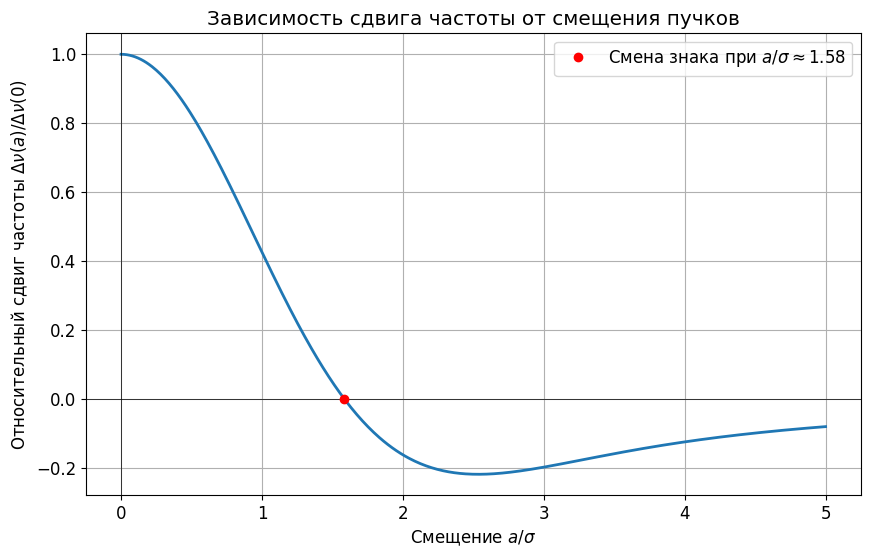

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def tune_shift_factor(a_over_sigma):
    """
    Вычисляет множитель ослабления сдвига частоты в зависимости от смещения a/sigma.
    u = a^2 / (2 sigma^2)
    Factor = (1/u) * [ exp(-u)*(2u+1) - 1 ]
    """
    # Обработка случая a=0 (деление на ноль)
    a_over_sigma = np.array(a_over_sigma)
    u = (a_over_sigma**2) / 2.0
    
    # Используем np.where для безопасного вычисления в нуле
    # В пределе u->0 значение равно 1.0
    
    with np.errstate(divide='ignore', invalid='ignore'):
        val = (np.exp(-u) * (2*u + 1) - 1) / u
    
    val = np.where(u < 1e-10, 1.0, val)
    return val

# Диапазон смещений a/sigma от 0 до 5
x = np.linspace(0, 5, 500)
y = tune_shift_factor(x)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(x, y, linewidth=2)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.title('Зависимость сдвига частоты от смещения пучков')
plt.xlabel('Смещение $a / \sigma$')
plt.ylabel('Относительный сдвиг частоты $\Delta \\nu(a) / \Delta \\nu(0)$')
plt.grid(True)

# Найдем точку пересечения нуля (где фокусировка меняется на дефокусировку)
# e^-u (2u+1) = 1
# Это происходит при u ~ 1.25 -> a/sigma ~ 1.58
zero_crossing_idx = np.where(np.diff(np.sign(y)))[0]
if len(zero_crossing_idx) > 0:
    x_zero = x[zero_crossing_idx[0]]
    plt.plot(x_zero, 0, 'ro', label=f'Смена знака при $a/\sigma \\approx {x_zero:.2f}$')
    plt.legend()

plt.show()